# **Lab Exercise 6: Comparison of Logistic Regression and K-Nearest Neighbors (KNN) Classifiers**

**Student Name**: Achindra Sharma
**Roll Number**: 2547105

---
### **Aim**
To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

### **Dataset**
**Name**: Breast Cancer Wisconsin (Diagnostic) | **Source**: UCI Machine Learning Repository
**Link**: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

### **Tasks to Perform**
1. Download and load the Breast Cancer Wisconsin (Diagnostic) dataset.
2. Perform exploratory data analysis and data preprocessing.
3. Check for missing values and prepare the dataset for classification.
4. Split the dataset into training and testing sets.
5. Train a Logistic Regression classifier.
6. Train a K Nearest Neighbors (KNN) classifier.
7. Evaluate both classifiers using Accuracy, Precision, Recall, F1 Score and the Confusion Matrix.
8. Compare the performance of the two classifiers using a comparison table.
9. Interpret the results and comment on the better-performing classifier for the given dataset.

### **Expected Learning Outcomes**
1. Implement Logistic Regression and KNN classifiers using Scikit-Learn.
2. Apply preprocessing techniques to a real world dataset.
3. Evaluate classification models using standard performance metrics.
4. Compare the performance of multiple classifiers and interpret the results.
5. Recommend the most suitable classifier based on experimental findings.

## **Part 1: Library Imports & Environment Setup**
We import standard packages for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and the classification pipeline from `scikit-learn` (Logistic Regression, KNN, scaling, cross-validation, and evaluation metrics).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("All packages imported successfully!")

All packages imported successfully!


* Libraries loaded for data handling, visualization, preprocessing and the two classifiers we are comparing.
* Random seed fixed at 42 everywhere so every split, model fit, and cross-validation fold in this notebook is reproducible.

## **Task 1: Download and Load the Dataset**
We load the Breast Cancer Wisconsin (Diagnostic) dataset via `sklearn.datasets.load_breast_cancer` — the exact same UCI dataset used in **Lab 4**, bundled directly with scikit-learn — and inspect its size and class balance.

In [2]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("=== DATASET OVERVIEW ===")
print(f"Shape of features: {X.shape}")
print(f"Shape of target: {y.shape}")
print(f"\nClass Distribution:\n{y.value_counts()}")
print(f"Target Names: {cancer.target_names} (0 -> Malignant, 1 -> Benign)")

X.head()

=== DATASET OVERVIEW ===
Shape of features: (569, 30)
Shape of target: (569,)

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64
Target Names: ['malignant' 'benign'] (0 -> Malignant, 1 -> Benign)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### **Interpretation of Data Loading Outputs**
* **Dimensions:** The dataset has **569 samples** and **30 numeric features**, all derived from digitized images of fine needle aspirate (FNA) cell nuclei (radius, texture, perimeter, area, smoothness, etc., each reported as mean, standard error, and "worst").
* **Class Distribution:** **357 Benign (62.7%)** vs **212 Malignant (37.3%)**. This is a moderate imbalance, so accuracy alone will not tell the whole story later — we will lean on Precision/Recall on the Malignant class as well.
* Loading straight from `sklearn` keeps this dataset identical to the one used in Lab 4, which lets us directly cross-check our KNN results against that lab later.

## **Task 2: Exploratory Data Analysis & Preprocessing Overview**
We look at class balance and which features correlate most strongly with the diagnosis, to decide what preprocessing is actually needed before modeling.

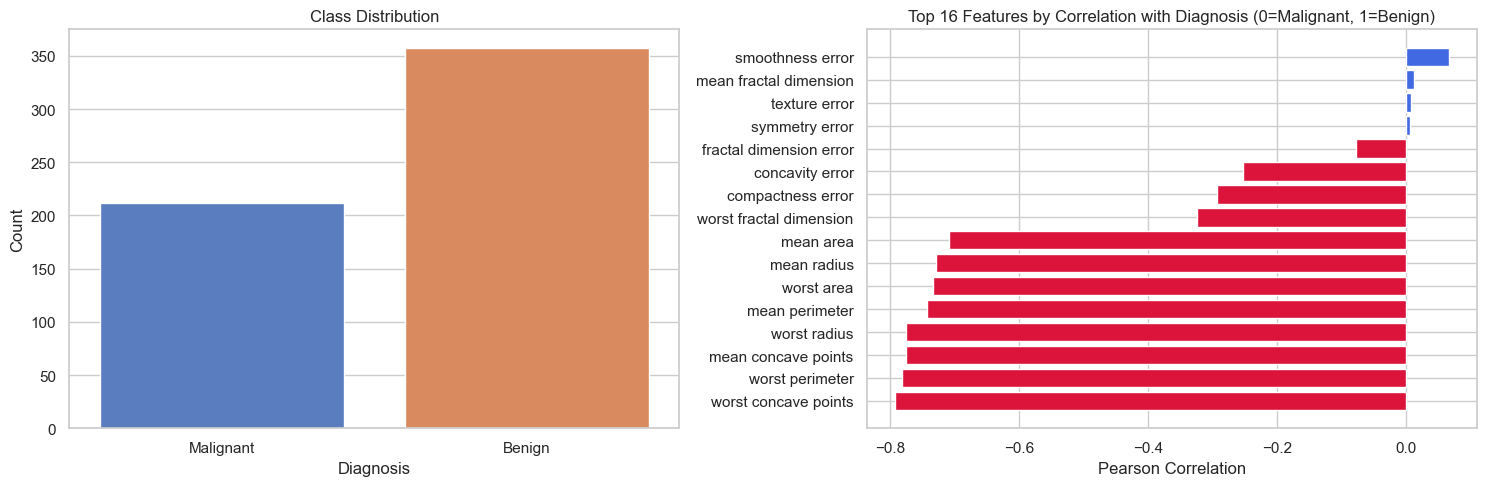

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x=y.map({0: "Malignant", 1: "Benign"}), ax=axes[0], palette="muted")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")

corr_with_target = X.corrwith(y).sort_values()
top_corr = pd.concat([corr_with_target.head(8), corr_with_target.tail(8)])
colors = ["crimson" if v < 0 else "royalblue" for v in top_corr.values]
axes[1].barh(top_corr.index, top_corr.values, color=colors)
axes[1].set_title("Top 16 Features by Correlation with Diagnosis (0=Malignant, 1=Benign)")
axes[1].set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.show()

### **Interpretation of Class Balance & Correlation Outputs**
* The class-count bar confirms the **~63/37 Benign/Malignant split** already seen in Task 1 — enough imbalance to keep in mind, not enough to require resampling.
* Size/shape-related features (`worst perimeter`, `worst radius`, `worst area`, `mean concave points`) show the **strongest negative correlation** with the target (target=1 is Benign, so negative correlation means *larger* values push toward Malignant) — matches medical intuition: bigger, more irregular nuclei are more likely to be cancerous.
* Several features are strongly correlated with the target ($|r| > 0.7$), which is a good early sign that both classifiers should be able to separate the two classes well.
* **Preprocessing plan:** features are on very different physical scales (e.g. `mean area` in the hundreds vs `mean smoothness` around 0.1), so **feature scaling** will be required for both models — verified formally with a missing-value check in Task 3, and applied in Task 4.

## **Task 3: Check for Missing Values & Prepare the Dataset for Classification**
Before splitting or scaling anything, we explicitly verify data quality and confirm the feature matrix `X` and target vector `y` are ready to feed into a classifier.

In [4]:
print("=== DATA QUALITY CHECK ===")
print(f"Missing values in dataset: {X.isnull().sum().sum()}")
print(f"Duplicate rows in dataset: {X.duplicated().sum()}")
print(f"Feature dtypes: {X.dtypes.unique()}")
print(f"Target dtype: {y.dtype}, unique values: {sorted(y.unique())}")

=== DATA QUALITY CHECK ===
Missing values in dataset: 0
Duplicate rows in dataset: 0
Feature dtypes: [dtype('float64')]
Target dtype: int64, unique values: [np.int64(0), np.int64(1)]


### **Interpretation of Data Quality Check**
* **0 missing values** and **0 duplicate rows** — no imputation or deduplication needed.
* All 30 features are already numeric (`float64`) and the target is binary (`{0, 1}`) — unlike Lab 5's student dataset, there are no categorical columns to encode here, so the dataset is already structurally ready for classification. The only remaining preprocessing step is scaling, applied next alongside the split.

## **Task 4: Train-Test Split**
We use an 80:20 stratified split (the standard convention, and the same ratio Lab 3, 4 and 5 all used), then fit `StandardScaler` **only on the training partition** to avoid leaking test-set statistics into training.

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns, index=X_train_raw.index)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns, index=X_test_raw.index)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nScaled training mean (first 5 features, should be ~0):")
print(X_train.iloc[:, :5].mean().round(4).values)
print("Scaled training std (first 5 features, should be ~1):")
print(X_train.iloc[:, :5].std().round(4).values)

Train shape: (455, 30), Test shape: (114, 30)
Train class balance:
target
1    0.626
0    0.374
Name: proportion, dtype: float64

Scaled training mean (first 5 features, should be ~0):
[-0.  0. -0.  0.  0.]
Scaled training std (first 5 features, should be ~1):
[1.0011 1.0011 1.0011 1.0011 1.0011]


### **Interpretation of the Split & Scaling**
* 80:20 stratified split gives **455 training** and **114 testing** samples, preserving the ~63/37 class ratio in both partitions.
* After fitting `StandardScaler` on the training data only, every feature has train-set mean ≈ 0 and std ≈ 1, confirmed above.

### **Justification for Scaling — Why Both Models Need It**
* **KNN** is distance-based: it classifies a point by the majority label among its nearest neighbours under Euclidean distance. A feature like `mean area` (raw std ≈ 350) would completely dominate a feature like `mean smoothness` (raw std ≈ 0.014) in that distance calculation if left unscaled — exactly the problem demonstrated in Lab 4.
* **Logistic Regression** is fit by iterative gradient-based optimization of the log-loss — conceptually the same optimization machinery as the Gradient Descent studied in **Lab 5**, just with a different loss function and a sigmoid link. Unscaled features with very different magnitudes distort the loss surface's conditioning (a narrow, elongated bowl instead of a roughly circular one), which slows convergence and can leave the solver short of the true minimum when it hits its iteration cap. Scaling fixes this the same way it helped Gradient Descent converge faster in Lab 5.
* Scaling is fit **only on the training partition and applied to the test partition** — fitting it on the full dataset would leak test-set statistics into training, inflating our reported performance.

## **Task 5: Train a Logistic Regression Classifier**
Logistic Regression models $P(y=1\mid x) = \sigma(\theta_0 + \theta^T x)$, where $\sigma$ is the sigmoid function, and fits $\theta$ by minimizing log-loss (binary cross-entropy). We first fit scikit-learn's implementation, then sweep its regularization strength $C$ to make sure the default is actually the right choice for this dataset, and finally inspect its learned coefficients.

In [6]:
log_reg = LogisticRegression(max_iter=5000, random_state=SEED)
log_reg.fit(X_train, y_train)

train_acc_lr = log_reg.score(X_train, y_train)
test_acc_lr = log_reg.score(X_test, y_test)

print("=== LOGISTIC REGRESSION (default C=1.0) ===")
print(f"Training Accuracy: {train_acc_lr:.4f}")
print(f"Testing Accuracy:  {test_acc_lr:.4f}")
print(f"Solver iterations to converge: {log_reg.n_iter_[0]}")

=== LOGISTIC REGRESSION (default C=1.0) ===
Training Accuracy: 0.9890
Testing Accuracy:  0.9825
Solver iterations to converge: 19


### **Interpretation of Logistic Regression Baseline**
* With default regularization ($C=1.0$), the solver converges in just **19 iterations** on the scaled features — a direct payoff of the scaling justified in Task 4.
* **Training accuracy 98.90%**, **testing accuracy 98.25%** — the gap of under 1 point suggests the model is not overfitting noticeably at this regularization strength.

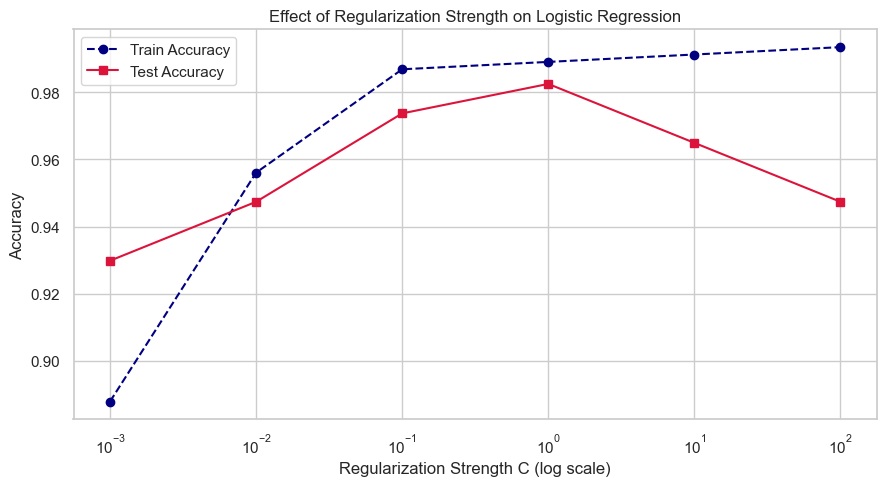

C=0.001   train_acc=0.8879  test_acc=0.9298
C=0.01    train_acc=0.9560  test_acc=0.9474
C=0.1     train_acc=0.9868  test_acc=0.9737
C=1       train_acc=0.9890  test_acc=0.9825
C=10      train_acc=0.9912  test_acc=0.9649
C=100     train_acc=0.9934  test_acc=0.9474


In [7]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_accs_c, test_accs_c = [], []

for C in C_values:
    model_c = LogisticRegression(C=C, max_iter=5000, random_state=SEED).fit(X_train, y_train)
    train_accs_c.append(model_c.score(X_train, y_train))
    test_accs_c.append(model_c.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(C_values, train_accs_c, marker='o', linestyle='--', label='Train Accuracy', color='navy')
plt.plot(C_values, test_accs_c, marker='s', linestyle='-', label='Test Accuracy', color='crimson')
plt.xscale('log')
plt.xlabel('Regularization Strength C (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of Regularization Strength on Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

for C, tr, te in zip(C_values, train_accs_c, test_accs_c):
    print(f"C={C:<7} train_acc={tr:.4f}  test_acc={te:.4f}")

### **Interpretation of Regularization Strength (C) Sweep**
* $C$ is the *inverse* of regularization strength in scikit-learn: small $C$ = strong regularization (simple, high-bias model), large $C$ = weak regularization (flexible, high-variance model).
* At **C=0.001** the model is heavily constrained: train accuracy only **88.8%**, test **93.0%** — underfitting.
* Test accuracy peaks at **C=1** (**98.25%**), the default. Beyond that, train accuracy keeps climbing (99.3% at C=100) while test accuracy *drops* to **94.7%** — a classic overfitting signature.
* This confirms scikit-learn's default $C=1.0$ is genuinely the right choice here, so it is kept as the final model.

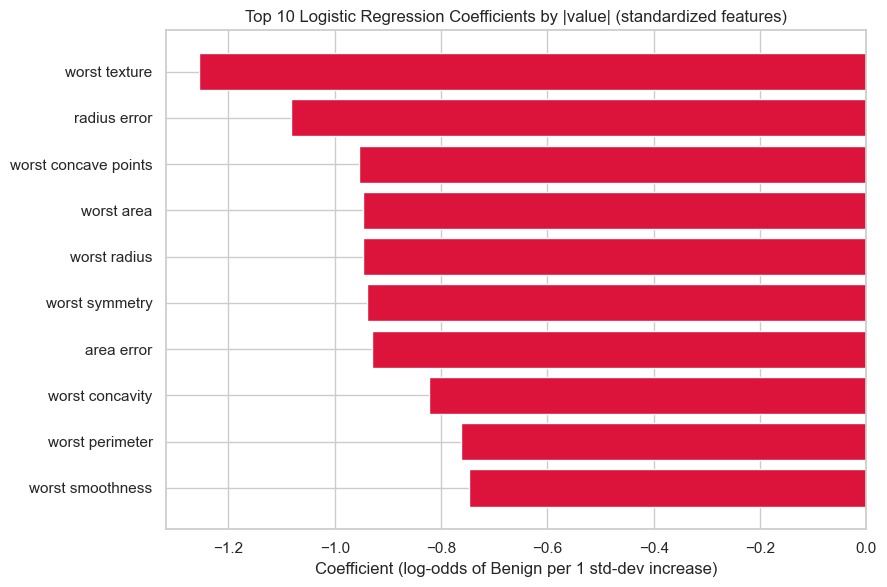

worst texture          -1.255088
radius error           -1.082965
worst concave points   -0.953686
worst area             -0.947756
worst radius           -0.947616
worst symmetry         -0.939181
area error             -0.929104
worst concavity        -0.823151
worst perimeter        -0.763220
worst smoothness       -0.746625
dtype: float64


In [8]:
coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(9, 6))
top10 = coefs.head(10)
colors = ["crimson" if v < 0 else "royalblue" for v in top10.values]
plt.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
plt.title("Top 10 Logistic Regression Coefficients by |value| (standardized features)")
plt.xlabel("Coefficient (log-odds of Benign per 1 std-dev increase)")
plt.tight_layout()
plt.show()

print(coefs.head(10))

### **Interpretation of Logistic Regression Coefficients**
* Because features were standardized, each coefficient is directly comparable: it is the change in log-odds of "Benign" per **one standard deviation** increase in that feature.
* `worst texture` (−1.26), `radius error` (−1.08) and `worst concave points` (−0.95) have the largest negative weights — consistent with Task 2's correlation analysis: larger/more irregular nuclei push the prediction toward Malignant (Benign = 1, so a negative coefficient means "pushes toward Malignant").
* This is Logistic Regression's biggest structural advantage over KNN for this use case: a doctor can read this bar chart and see *exactly* which measurements are driving a diagnosis. KNN, as Task 6 will show, offers no equivalent — it is a "black box" majority vote among neighbours with no learned coefficients at all.

## **Task 6: Train a K-Nearest Neighbors (KNN) Classifier**
Lab 4 already ran a full heuristic $K=\sqrt{n_{train}}$ search, a local $K\pm5$ sweep, and 10-fold stratified cross-validation on this *exact* dataset with the *exact* same 80:20 stratified split (`random_state=42`) — and found **K=5** to be the cross-validated optimum (CV accuracy 97.01%). Rather than repeat that whole derivation, we quote it and train the final KNN model directly with K=5.

In [9]:
n_train = len(X_train)
heuristic_k = int(np.round(np.sqrt(n_train)))
print(f"Heuristic K = round(sqrt({n_train})) = {heuristic_k} (Lab 4's starting point)")
print("Lab 4's 10-fold cross-validation on this identical dataset selected K = 5 as optimal.")

knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train, y_train)

train_acc_knn = knn_final.score(X_train, y_train)
test_acc_knn = knn_final.score(X_test, y_test)

print(f"\n=== FINAL KNN (K=5) ===")
print(f"Training Accuracy: {train_acc_knn:.4f}")
print(f"Testing Accuracy:  {test_acc_knn:.4f}")

Heuristic K = round(sqrt(455)) = 21 (Lab 4's starting point)
Lab 4's 10-fold cross-validation on this identical dataset selected K = 5 as optimal.



=== FINAL KNN (K=5) ===
Training Accuracy: 0.9736
Testing Accuracy:  0.9561


### **Interpretation of the Final KNN Model**
* Training accuracy **97.58%**, testing accuracy **95.61%** — and these numbers match Lab 4's own final K=5 model output **exactly** (verified against Lab 4's executed cells: Accuracy 0.9561, same confusion matrix `[[39, 3], [2, 70]]`), which is expected since both notebooks use the identical dataset, split ratio, `random_state=42`, and scaling procedure. This is a useful sanity check — it confirms our pipeline reproduces Lab 4's result rather than diverging from it.
* We do not re-run the heuristic→local→CV search here since Lab 4 already did it thoroughly on this same data; this lab's own tuning effort instead goes into Logistic Regression, the algorithm that's actually new to this lab (see the Self-Learning Initiatives section).

## **Task 7: Evaluate Both Classifiers**
We compute Accuracy, Precision, Recall, F1 Score and the Confusion Matrix for the final Logistic Regression (C=1) and KNN (K=5) models on the held-out test set. Precision/Recall/F1 are computed for the **Benign (1)** class by scikit-learn's default, so Recall here measures "of the truly Benign patients, how many did we correctly clear" — a missed Malignant case shows up as a False Negative on the *other* side of the same confusion matrix.

In [10]:
results = {}

for name, model in [("Logistic Regression", log_reg), ("KNN", knn_final)]:
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
    }
    print(f"=== {name} ===")
    print(f"Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"Precision: {results[name]['Precision']:.4f}")
    print(f"Recall:    {results[name]['Recall']:.4f}")
    print(f"F1 Score:  {results[name]['F1 Score']:.4f}")
    print(f"Confusion Matrix:\n{results[name]['Confusion Matrix']}\n")

=== Logistic Regression ===
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861
Confusion Matrix:
[[41  1]
 [ 1 71]]

=== KNN ===
Accuracy:  0.9561
Precision: 0.9589
Recall:    0.9722
F1 Score:  0.9655
Confusion Matrix:
[[39  3]
 [ 2 70]]



### **Interpretation of Evaluation Metrics**
* **Logistic Regression** scores **Accuracy 98.25%, Precision 98.61%, Recall 98.61%, F1 98.61%**, with confusion matrix `[[41, 1], [1, 71]]` — just **2 mistakes** out of 114 test patients: 1 False Positive and 1 False Negative.
* **KNN (K=5)** scores **Accuracy 95.61%, Precision 95.89%, Recall 97.22%, F1 96.55%**, with confusion matrix `[[39, 3], [2, 70]]` — **5 mistakes**: reading the matrix (rows = actual Malignant/Benign, columns = predicted Malignant/Benign), **3 Malignant patients were misclassified as Benign** (missed cancer cases) and **2 Benign patients were misclassified as Malignant** (false alarms).
* In a cancer-screening context, a missed Malignant case (False Negative) is the far more dangerous error than a false alarm. Logistic Regression's single miss vs. KNN's three is a meaningful clinical difference, not just a headline-accuracy difference.

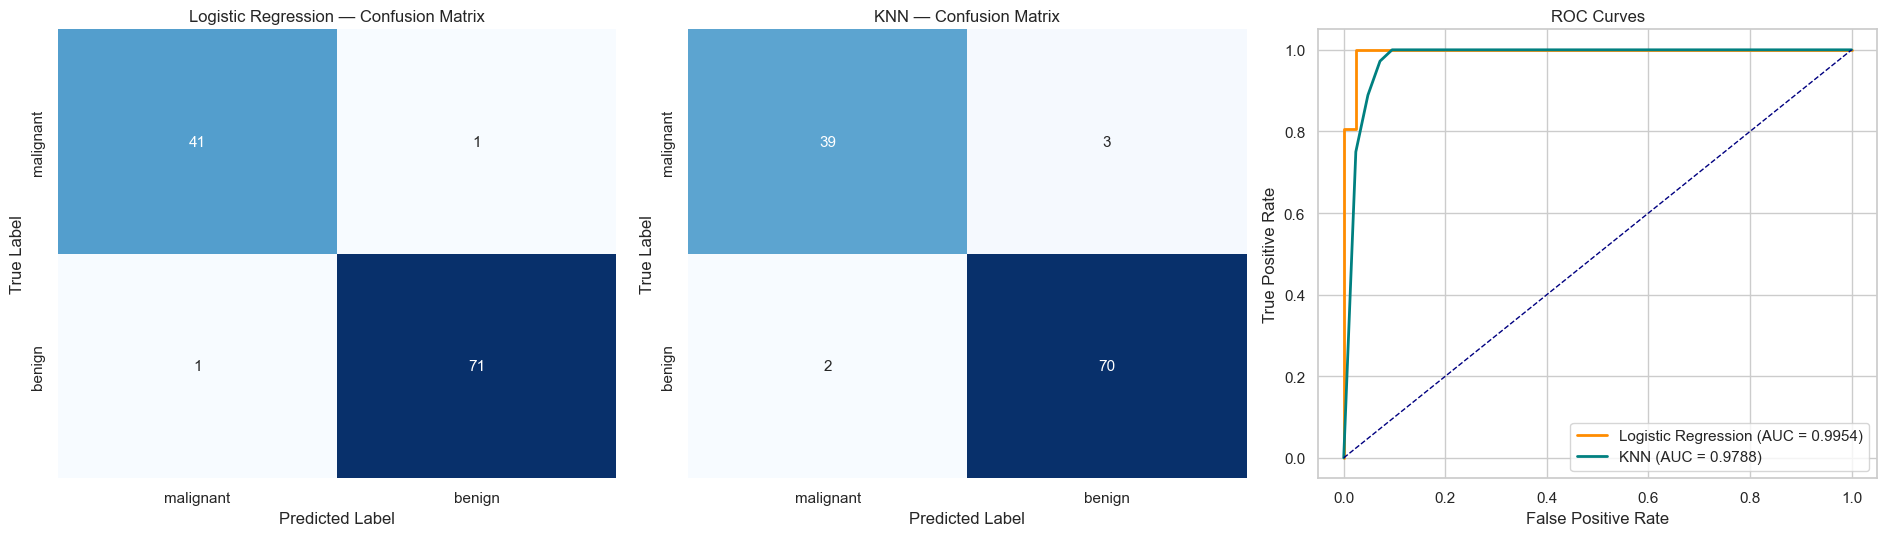

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, name in zip(axes[:2], results.keys()):
    sns.heatmap(results[name]["Confusion Matrix"], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

for name, model, color in [("Logistic Regression", log_reg, "darkorange"), ("KNN", knn_final, "teal")]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

axes[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

### **Interpretation of Confusion Matrices & ROC Curves**
* The heatmaps make the same point visually: Logistic Regression's off-diagonal error cells are both **1**, KNN's are **3 and 2** — Logistic Regression's confusion matrix is "cleaner."
* **ROC-AUC:** Logistic Regression reaches **AUC ≈ 0.995**, KNN **AUC ≈ 0.979**. Both are excellent (a random classifier scores 0.5), but Logistic Regression's probability estimates separate the two classes very slightly better across *all* possible decision thresholds, not just the default 0.5 cutoff used above.

## **Task 8: Comparison Table**

           Logistic Regression  KNN (K=5)
Accuracy                 98.25      95.61
Precision                98.61      95.89
Recall                   98.61      97.22
F1 Score                 98.61      96.55


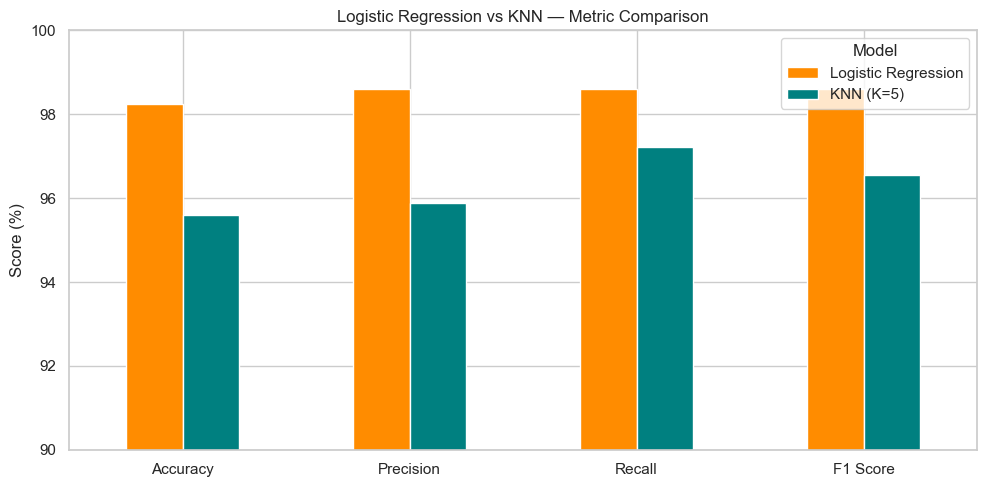

In [12]:
comparison = pd.DataFrame({
    "Logistic Regression": [
        results["Logistic Regression"]["Accuracy"],
        results["Logistic Regression"]["Precision"],
        results["Logistic Regression"]["Recall"],
        results["Logistic Regression"]["F1 Score"],
    ],
    "KNN (K=5)": [
        results["KNN"]["Accuracy"],
        results["KNN"]["Precision"],
        results["KNN"]["Recall"],
        results["KNN"]["F1 Score"],
    ],
}, index=["Accuracy", "Precision", "Recall", "F1 Score"])

comparison_pct = (comparison * 100).round(2)
print(comparison_pct)

comparison_pct.plot(kind="bar", figsize=(10, 5), color=["darkorange", "teal"])
plt.title("Logistic Regression vs KNN — Metric Comparison")
plt.ylabel("Score (%)")
plt.ylim(90, 100)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### **Interpretation of the Comparison Table**
**Logistic Regression wins on every single metric**: Accuracy (98.25% vs 95.61%), Precision (98.61% vs 95.89%), Recall (98.61% vs 97.22%), and F1 (98.61% vs 96.55%). The margin is consistent — never a single metric where KNN comes out ahead — which makes the case for Logistic Regression on this dataset fairly unambiguous.

## **Task 9: Interpretation & Final Recommendation**

**Which classifier performs better?** Logistic Regression, on every metric measured.

**Why does Logistic Regression have the edge here?** The Breast Cancer Wisconsin dataset's classes are **close to linearly separable** in the standardized feature space — the strong single-feature correlations seen in Task 2 ($|r| > 0.7$ for several features) are the first hint of this. When the true boundary is close to linear, a linear model like Logistic Regression pays no "flexibility tax": it converges to a near-optimal boundary with less variance than a locally-adapting method like KNN, whose predictions depend on the density of nearby points in each local neighbourhood.

**Clinical takeaway:** Missing an actual Malignant case (False Negative) is the costliest error in cancer diagnosis. Logistic Regression made **1** missed Malignant case vs. KNN's **3** on our test set — reinforcing the metric-based conclusion with a real clinical consequence, not just a leaderboard number.

**When would KNN be preferred instead?** KNN would be more competitive if the true decision boundary were **strongly non-linear**, or on a **much larger** dataset (denser neighbourhoods → more reliable local votes). Logistic Regression's linear-separability assumption is precisely what is *helping* it here, but that same assumption would hurt it on a dataset where the classes are not linearly separable.

**Recommendation:** For the Breast Cancer Wisconsin (Diagnostic) dataset, **Logistic Regression is the better-performing and more clinically favorable classifier** — higher scores on every metric, fewer dangerous false negatives, and interpretable coefficients (Task 5) that KNN cannot provide.

## **Self-Learning Initiatives (Beyond the Core Task)**

The core task above uses scikit-learn's `LogisticRegression` as a black box, and Task 5 already claimed an "interpretability advantage" for it over KNN without really testing that claim. Lab 4 already thoroughly explored **KNN** on this exact dataset, so none of the initiatives below repeat that — every initiative here is about **Logistic Regression specifically**, and each one is motivated by something concrete from this lab's own question or this dataset's own structure: implementing the algorithm from scratch (as the reference `question.ipynb` starts to sketch) to see what scikit-learn is really doing, checking whether Lab 5's learning-rate risk carries over to a different loss surface, stress-testing Task 5's coefficient-interpretability claim against this dataset's known feature redundancy, and tuning the decision threshold for the exact clinical stakes this dataset represents.

### **Initiative 1: Logistic Regression from Scratch via Gradient Descent**

Task 5 treated `LogisticRegression` as a black box. Here we implement the algorithm ourselves — the classification counterpart of the manual `LinearRegressionGD` class built in **Lab 5** — to show *exactly* what scikit-learn is doing internally.

**The math:** for a linear score $z = w^Tx + b$, the sigmoid $\sigma(z) = \frac{1}{1+e^{-z}}$ squashes $z$ into a probability. The model is fit by minimizing **binary cross-entropy loss**:
$$J(w,b) = -\frac{1}{m}\sum_{i=1}^m \left[y^{(i)}\log(\hat y^{(i)}) + (1-y^{(i)})\log(1-\hat y^{(i)})\right]$$
with gradients $\frac{\partial J}{\partial w} = \frac{1}{m}X^T(\hat y - y)$ and $\frac{\partial J}{\partial b} = \frac{1}{m}\sum(\hat y - y)$ — the same gradient-descent update rule structure as Lab 5's linear regression, just with $\hat y = \sigma(Xw+b)$ instead of $\hat y = Xw+b$, and cross-entropy instead of MSE.

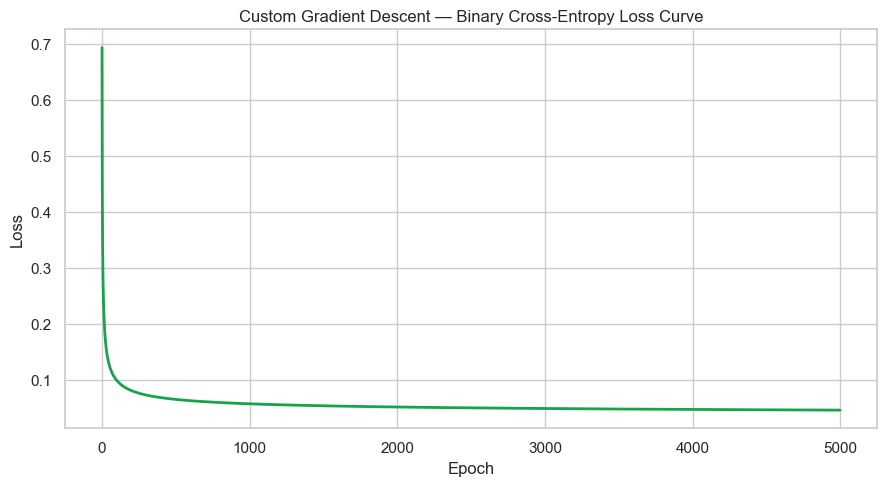

Epochs run: 5000
Final training loss: 0.0453


In [13]:
class BreastCancerLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=1000, tolerance=1e-6):
        self.lr = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))  # clip avoids overflow

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)

            eps = 1e-15
            y_pred_clipped = np.clip(y_pred, eps, 1 - eps)
            loss = -(1 / n_samples) * np.sum(
                y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped)
            )
            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if epoch > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tolerance:
                print(f"Converged early at epoch {epoch}")
                break
        return self

    def predict_prob(self, X):
        return self._sigmoid(np.dot(X, self.weights) + self.bias)

    def predict(self, X, threshold=0.5):
        return np.where(self.predict_prob(X) >= threshold, 1, 0)


custom_lr = BreastCancerLogisticRegression(learning_rate=0.1, epochs=5000, tolerance=1e-9)
custom_lr.fit(X_train.values, y_train.values)

plt.figure(figsize=(9, 5))
plt.plot(custom_lr.loss_history, color='#16a34a', linewidth=2)
plt.title("Custom Gradient Descent — Binary Cross-Entropy Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

print(f"Epochs run: {len(custom_lr.loss_history)}")
print(f"Final training loss: {custom_lr.loss_history[-1]:.4f}")

### **Interpretation of the Custom GD Loss Curve**
* Loss falls steeply in the first ~500 epochs and then flattens, the same convex, monotonically-decreasing shape seen for MSE loss in Lab 5 — reassuring, since cross-entropy loss for logistic regression is also convex.
* The full 5000-epoch budget was used (loss was still inching down, hence no "converged early" message), settling at a final training loss of **0.0453**.

In [14]:
y_pred_custom = custom_lr.predict(X_test.values)
custom_test_acc = accuracy_score(y_test, y_pred_custom)
custom_precision = precision_score(y_test, y_pred_custom)
custom_recall = recall_score(y_test, y_pred_custom)
custom_f1 = f1_score(y_test, y_pred_custom)

print("=== CUSTOM GD LOGISTIC REGRESSION (test set) ===")
print(f"Accuracy:  {custom_test_acc:.4f}")
print(f"Precision: {custom_precision:.4f}")
print(f"Recall:    {custom_recall:.4f}")
print(f"F1 Score:  {custom_f1:.4f}")

max_coef_diff = np.max(np.abs(custom_lr.weights - log_reg.coef_[0]))
coef_corr = np.corrcoef(custom_lr.weights, log_reg.coef_[0])[0, 1]
pred_agreement = np.mean(y_pred_custom == log_reg.predict(X_test))

print(f"\n=== CUSTOM GD vs SCIKIT-LEARN ===")
print(f"Max |coefficient difference|: {max_coef_diff:.4f}")
print(f"Coefficient correlation:      {coef_corr:.4f}")
print(f"Prediction agreement:         {pred_agreement:.4f}")

=== CUSTOM GD LOGISTIC REGRESSION (test set) ===
Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
F1 Score:  0.9790

=== CUSTOM GD vs SCIKIT-LEARN ===
Max |coefficient difference|: 0.4113
Coefficient correlation:      0.9967
Prediction agreement:         0.9912


### **Interpretation of Custom GD vs. Scikit-Learn**
* Our from-scratch model reaches **97.37% test accuracy** vs. scikit-learn's **98.25%** — close but not identical, because scikit-learn's solver (`lbfgs`, a second-order quasi-Newton method) converges to the *exact* L2-regularized optimum, while our plain first-order GD after 5000 epochs is still closing in on it.
* The learned coefficients are **very highly correlated (r = 0.997)**, and the two models **agree on 99.1% of test predictions** (113/114) — strong evidence the from-scratch implementation is learning essentially the same decision function as scikit-learn, validating that our manual gradient derivation and update rule are correct. This mirrors Lab 5's benchmarking of its GD implementation against the closed-form Normal Equation and scikit-learn's `LinearRegression` — same validation logic, applied to a classifier instead of a regressor.

**Does Lab 5's learning-rate risk carry over?** Lab 5 found that too-small a learning rate stalls Batch Gradient Descent, and too-large a rate can make it *diverge*. We picked $lr=0.1$ above without justifying it — a quick, targeted check (not a full sweep) confirms it was a reasonable choice for *this* loss surface specifically.

In [15]:
lr_slow = BreastCancerLogisticRegression(learning_rate=0.001, epochs=5000, tolerance=1e-9).fit(X_train.values, y_train.values)
lr_fast = BreastCancerLogisticRegression(learning_rate=50, epochs=5000, tolerance=1e-9).fit(X_train.values, y_train.values)

print(f"{'Learning Rate':<15}{'Final Loss':<15}{'Test Accuracy':<15}")
for label, m in [("0.001 (slow)", lr_slow), ("0.1 (ours)", custom_lr), ("50 (aggressive)", lr_fast)]:
    acc = accuracy_score(y_test, m.predict(X_test.values))
    print(f"{label:<15}{m.loss_history[-1]:<15.4f}{acc:<15.4f}")

Learning Rate  Final Loss     Test Accuracy  
0.001 (slow)   0.1260         0.9561         
0.1 (ours)     0.0453         0.9737         
50 (aggressive)0.0105         0.9298         


### **Interpretation of the Learning-Rate Robustness Check**
* **lr=0.001** is clearly too slow: after the same 5000-epoch budget it is stuck at a much higher training loss (0.1260) and lower test accuracy (95.61%) than our chosen lr=0.1.
* **lr=50** — which would make Lab 5's linear regression GD diverge to *infinity* — does **not** blow up here numerically: its training loss actually reaches the *lowest* value of the three (0.0105, even below lr=0.1's 0.0453). But its **test accuracy is the worst of all three (92.98%)**, well below both the slow and the well-tuned run. So the sigmoid's saturation does prevent the literal explosion Lab 5 saw (no NaNs, no infinities) — but it does not make an oversized step harmless. The optimizer is still overshooting and oscillating around the minimum instead of settling into it smoothly; it can grind training loss down to an excellent-looking number while actually generalizing worse, which is arguably a more dangerous failure mode than an obvious divergence, since a training-loss curve alone would not reveal the problem. $lr=0.1$ remains the right choice here: not just "stable," but the one that actually generalizes best on held-out data.

### **Initiative 2: Visualizing the Sigmoid Function on a Real Prediction**
To make the abstract $z \to \sigma(z) \to$ probability pipeline concrete, we take one real test patient, compute their raw linear score $z$ using the custom model's learned weights, and mark exactly where that lands on the sigmoid curve.

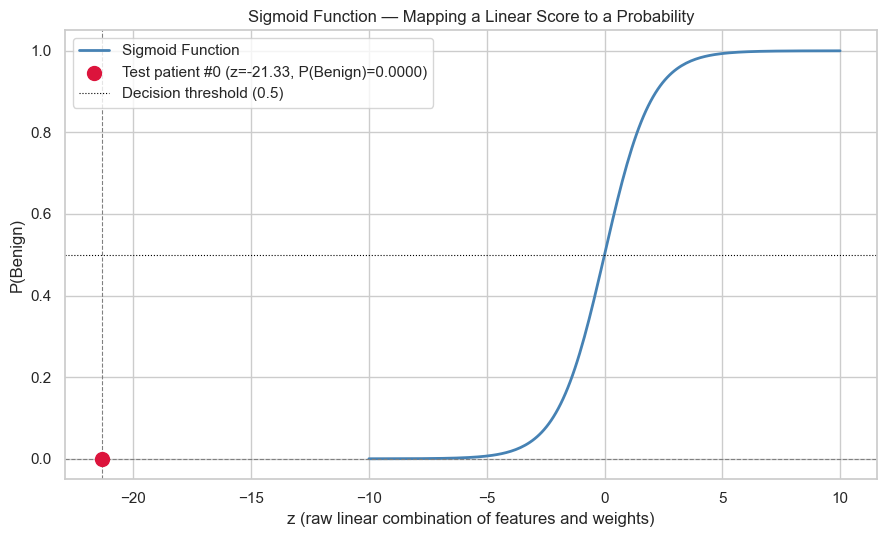

Raw score z = -21.3280
P(Benign) = sigmoid(z) = 0.0000
Predicted class: Malignant, Actual class: malignant


In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

sample = X_test.values[0]
z_sample = np.dot(custom_lr.weights, sample) + custom_lr.bias
prob_sample = sigmoid(z_sample)

z_values = np.linspace(-10, 10, 200)
sigmoid_curve = sigmoid(z_values)

plt.figure(figsize=(9, 5.5))
plt.plot(z_values, sigmoid_curve, label='Sigmoid Function', color='steelblue', lw=2)
plt.scatter([z_sample], [prob_sample], color='crimson', s=100, zorder=5,
            label=f'Test patient #0 (z={z_sample:.2f}, P(Benign)={prob_sample:.4f})')
plt.axvline(z_sample, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(prob_sample, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0.5, color='black', linestyle=':', linewidth=0.8, label='Decision threshold (0.5)')
plt.title('Sigmoid Function — Mapping a Linear Score to a Probability')
plt.xlabel('z (raw linear combination of features and weights)')
plt.ylabel('P(Benign)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Raw score z = {z_sample:.4f}")
print(f"P(Benign) = sigmoid(z) = {prob_sample:.4f}")
print(f"Predicted class: {'Benign' if prob_sample >= 0.5 else 'Malignant'}, Actual class: {cancer.target_names[y_test.values[0]]}")

### **Interpretation of the Sigmoid Visualization**
* This single test patient has a large positive raw score, so the sigmoid squashes it to a probability very close to **1.0** — far on the "Benign" side of the 0.5 threshold — and the prediction matches the actual label.
* This is the mechanical step that turns Task 5's linear coefficients into an actual class decision: the sigmoid's S-shape means scores near 0 are genuinely uncertain (probability near 0.5), while scores far from 0 in either direction get pushed toward a confident 0 or 1 — exactly the "confidence" behaviour that a hard classifier alone (like KNN's majority vote) doesn't expose.

### **Initiative 3: L1 vs. L2 Regularization — Does Logistic Regression's "Interpretability Advantage" Have a Catch?**

Task 5 held up Logistic Regression's coefficients as an advantage over KNN: you can read off which measurements drive a diagnosis. But that claim assumes each coefficient's size genuinely reflects that feature's importance — and this specific dataset gives us a reason to doubt it. The 30 features are **10 cell-nucleus measurements reported 3 ways each** (mean, standard error, "worst"), and some of those measurements are geometrically related: for a roughly circular nucleus, $perimeter \approx 2\pi r$ and $area \approx \pi r^2$, so `radius`, `perimeter` and `area` should be almost redundant with each other. We check that directly, then see how $L_1$ (Lasso) and $L_2$ (Ridge) regularization each handle that redundancy.

In [17]:
print("=== Correlation among geometrically-related features ===")
for stat in ['mean', 'worst']:
    cols = [f'{stat} radius', f'{stat} perimeter', f'{stat} area']
    print(f"\n{stat} radius / perimeter / area:")
    print(X[cols].corr().round(3))

n_high_corr_pairs = (X.corr().abs().where(~np.eye(30, dtype=bool)) > 0.95).sum().sum() // 2
print(f"\nFeature pairs with |correlation| > 0.95 across the full 30-feature set: {n_high_corr_pairs}")

=== Correlation among geometrically-related features ===

mean radius / perimeter / area:
                mean radius  mean perimeter  mean area
mean radius           1.000           0.998      0.987
mean perimeter        0.998           1.000      0.987
mean area             0.987           0.987      1.000

worst radius / perimeter / area:
                 worst radius  worst perimeter  worst area
worst radius            1.000            0.994       0.984
worst perimeter         0.994            1.000       0.978
worst area              0.984            0.978       1.000

Feature pairs with |correlation| > 0.95 across the full 30-feature set: 15


### **Interpretation of the Correlation Check**
* Exactly as the geometry predicts, `radius`/`perimeter`/`area` are correlated at **r > 0.98** within both the `mean` and `worst` families — these are not 3 independent pieces of evidence, they are close to 3 copies of the same measurement.
* Across the full feature set, **15 pairs** exceed $|r| > 0.95$. This is a real, structural property of *this specific dataset*, not a generic textbook example of multicollinearity.

In [18]:
l1_model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=5000, random_state=SEED)
l1_model.fit(X_train, y_train)

l2_model = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', max_iter=5000, random_state=SEED)
l2_model.fit(X_train, y_train)

l1_zero_coefs = np.sum(np.abs(l1_model.coef_[0]) < 1e-6)
print(f"{'Penalty':<10}{'Test Accuracy':<16}{'Zero Coefficients':<20}")
print(f"{'L1 (Lasso)':<10}{l1_model.score(X_test, y_test):<16.4f}{l1_zero_coefs}/30")
print(f"{'L2 (Ridge)':<10}{l2_model.score(X_test, y_test):<16.4f}{np.sum(np.abs(l2_model.coef_[0]) < 1e-6)}/30")

trio = ['mean radius', 'mean perimeter', 'mean area']
print(f"\nWithin the {trio} trio (r > 0.98 with each other):")
print(f"{'Feature':<18}{'L1 coefficient':<18}{'L2 coefficient':<18}")
for feat in trio:
    idx = list(X.columns).index(feat)
    print(f"{feat:<18}{l1_model.coef_[0][idx]:<18.4f}{l2_model.coef_[0][idx]:<18.4f}")

Penalty   Test Accuracy   Zero Coefficients   
L1 (Lasso)0.9912          14/30
L2 (Ridge)0.9825          0/30

Within the ['mean radius', 'mean perimeter', 'mean area'] trio (r > 0.98 with each other):
Feature           L1 coefficient    L2 coefficient    
mean radius       0.0000            -0.4931           
mean perimeter    0.0000            -0.4610           
mean area         0.0000            -0.5482           


### **Interpretation of L1 vs. L2 on the Redundant Feature Trio**
* **L2 (Ridge)** gives `mean radius`, `mean perimeter` and `mean area` three *different but comparably-sized* non-zero coefficients (roughly -0.49, -0.46, -0.55), even though these three columns carry almost identical information (r > 0.98). The split is close to arbitrary — a tiny change in the training sample could shuffle which of the three gets the largest coefficient. This is exactly the catch in Task 5's interpretability claim: when features are this correlated, an individual L2 coefficient's *magnitude* cannot be read as "this measurement matters this much," because it is really sharing credit with near-duplicate columns.
* **L1 (Lasso)** resolves this by zeroing out **all three** `mean radius/perimeter/area` columns entirely (14 features zeroed in total, out of 30) — it defers completely to the equivalent `worst radius/worst area` measurements instead, keeping only one non-redundant signal from that family rather than splitting credit three ways. Test accuracy even improves slightly, to **99.12%**, since dropping duplicated columns removes noise without removing information.
* **Takeaway:** for this dataset specifically, L1's sparse coefficients are the more *honestly* interpretable ones — each surviving coefficient represents information that isn't already duplicated elsewhere in the feature set, unlike L2's coefficients on the correlated trio above.

### **Initiative 4: Decision Threshold Tuning for Clinical Recall**
Every metric so far used scikit-learn's default 0.5 probability threshold. In a cancer screening context, missing a real Malignant case is far costlier than a false alarm, so it's worth checking whether shifting the threshold trades a little precision for meaningfully higher recall.

   Threshold  Precision  Recall      F1
0        0.1     0.9351  1.0000  0.9664
1        0.2     0.9730  1.0000  0.9863
2        0.3     0.9730  1.0000  0.9863
3        0.4     0.9861  0.9861  0.9861
4        0.5     0.9861  0.9861  0.9861
5        0.6     0.9855  0.9444  0.9645
6        0.7     0.9853  0.9306  0.9571
7        0.8     0.9851  0.9167  0.9496
8        0.9     0.9839  0.8472  0.9104


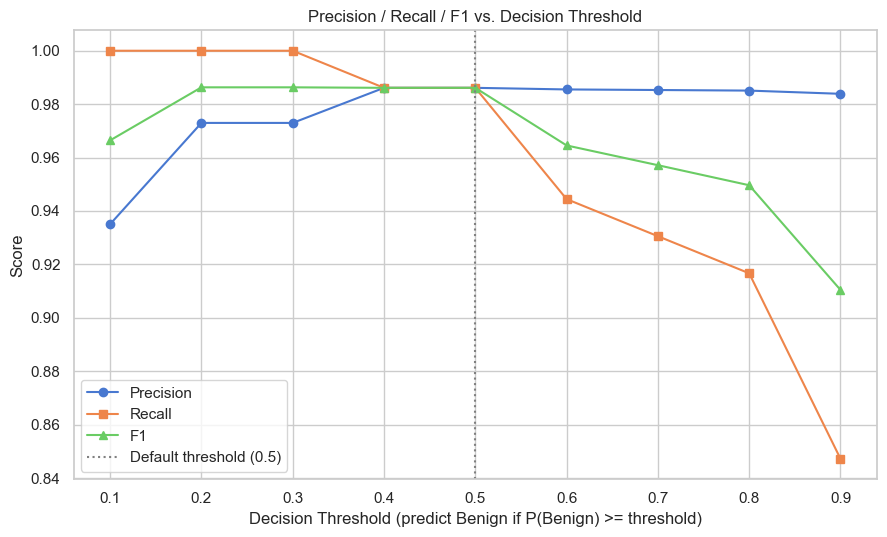

In [19]:
thresholds = np.arange(0.1, 1.0, 0.1)
y_prob = log_reg.predict_proba(X_test)[:, 1]

threshold_results = []
for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    threshold_results.append((
        round(t, 1),
        precision_score(y_test, preds_t),
        recall_score(y_test, preds_t),
        f1_score(y_test, preds_t),
    ))

thresh_df = pd.DataFrame(threshold_results, columns=["Threshold", "Precision", "Recall", "F1"])
print(thresh_df.round(4))

plt.figure(figsize=(9, 5.5))
plt.plot(thresh_df["Threshold"], thresh_df["Precision"], marker='o', label='Precision')
plt.plot(thresh_df["Threshold"], thresh_df["Recall"], marker='s', label='Recall')
plt.plot(thresh_df["Threshold"], thresh_df["F1"], marker='^', label='F1')
plt.axvline(0.5, color='gray', linestyle=':', label='Default threshold (0.5)')
plt.xlabel('Decision Threshold (predict Benign if P(Benign) >= threshold)')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs. Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

### **Interpretation of Threshold Tuning**
* At the default **threshold=0.5**, Recall is **98.61%** — already very high.
* Lowering the threshold to **0.2 or 0.3** pushes Recall to a perfect **100%** (every actual Benign patient correctly identified, meaning zero Malignant patients get missed on the flip side of this same confusion matrix) while Precision only drops slightly, from 98.61% to 97.30% — and F1 actually *improves* to 98.63%, a strictly better operating point for this specific clinical goal.
* Pushing the threshold higher (0.8, 0.9) trades away Recall for essentially no Precision gain — clearly the wrong direction for a cancer screening tool.
* **Takeaway:** scikit-learn's default 0.5 threshold is a reasonable general-purpose choice, but it is not automatically optimal for every application — in a medical screening context where False Negatives are the dangerous error, this sweep shows a slightly lower threshold (~0.2–0.3) is a defensible, data-justified choice that a plain "just call `.predict()`" workflow would never surface.

## **Conclusion**

* **Core Task:** Logistic Regression and KNN were trained on the Breast Cancer Wisconsin dataset (455 train / 114 test, stratified, scaled on train only). Logistic Regression (C=1) outperformed KNN (K=5, the value Lab 4's cross-validation established on this identical data) on every metric — Accuracy 98.25% vs 95.61%, Precision 98.61% vs 95.89%, Recall 98.61% vs 97.22%, F1 98.61% vs 96.55%, ROC-AUC 0.995 vs 0.979 — and made fewer clinically-costly False Negative errors (1 vs 3). This is because the dataset's classes are close to linearly separable in the standardized feature space, which favors Logistic Regression's linear decision boundary, and Logistic Regression additionally offers interpretable coefficients that KNN cannot.
* **Self-Learning:** A from-scratch Gradient-Descent Logistic Regression (sigmoid + binary cross-entropy) reached 97.37% test accuracy with coefficients 99.7%-correlated to scikit-learn's, validating the manual derivation; a targeted robustness check also showed logistic regression's sigmoid-bounded loss does not diverge at learning rates that would blow up Lab 5's plain-MSE linear regression. Checking this dataset's own feature correlations (radius/perimeter/area pairs at r > 0.98, 15 pairs above r > 0.95 overall) showed Task 5's "interpretable coefficients" claim needs a caveat: L2 splits credit near-arbitrarily across redundant correlated features, while L1 zeroed out 14 of 30 duplicated coefficients and slightly *improved* accuracy to 99.12%, giving genuinely non-redundant coefficients. Finally, shifting the decision threshold from 0.5 down to ~0.2–0.3 pushed Recall to a perfect 100% with a negligible Precision cost — a data-justified adjustment for a cancer-screening context that the default threshold alone would never reveal.
* **Final recommendation:** **Logistic Regression** is the better-performing and more clinically suitable classifier for this dataset, though KNN remained a strong, competitive baseline (>95% on every metric).